# Inspect Pipeline Output
Replicates and tests the pipeline's plotting functions directly from the NetCDF output files.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, configparser
sys.path.insert(0, "/home/kbrennan/balloon_optimizer")

import run_pipeline as rp          # all plotting/loading functions live here
import xarray as xr
import matplotlib.pyplot as plt

In [ ]:
RUN_DIR = "/net/litho/atmosdyn2/kbrennan/data/balloon/solutions/ifs_ensemble_test_20260222_12_20260224_12_20260226_163459"

cfg = configparser.ConfigParser(inline_comment_prefixes=("#",))
cfg.read(os.path.join(RUN_DIR, "params.txt"))

START_LAT = cfg.getfloat("origin", "start_lat")
START_LON = cfg.getfloat("origin", "start_lon")

# Discover which member_ subdirectories were actually produced
MEMBERS = sorted([
    d.replace("member_", "")
    for d in os.listdir(RUN_DIR)
    if d.startswith("member_") and os.path.isdir(os.path.join(RUN_DIR, d))
])

print(f"Run dir : {RUN_DIR}")
print(f"Origin  : {START_LAT}°N  {START_LON}°E")
print(f"Members : {MEMBERS}")

Run dir  : /net/litho/atmosdyn2/kbrennan/data/balloon/solutions/ifs_ensemble_test_20260222_12_20260224_12_20260226_163459
Origin   : 51.963517°N  7.61565°E
Members  : ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']


: 

: 

In [ ]:
# Plotting helpers are defined in run_pipeline.py and accessed via `rp`.
#
#   rp.plot_member_from_nc(member_dir, member, start_lat, start_lon)
#       -> (fig_map, fig_pressure)  – map + pressure profiles for all k_best trajectories
#
#   rp.plot_member_by_target(member_dir, member, target_lat, target_lon, radius_km=200)
#       -> fig_pressure | None      – profiles of trajectories ending near a target point
#
#   rp.plot_probabilistic_from_nc(run_dir, members, start_lat, start_lon)
#       -> dict of figures           – fraction-reachable map, histogram, (landing-zone overlays)
print("run_pipeline version:", getattr(rp, "__version__", "n/a"))
print("Available plotting helpers:", [n for n in dir(rp) if n.startswith("plot_")])

: 

: 

## Per-member plots
Loop over all members, load their NetCDF output and display the trajectory map and pressure profiles.

In [ ]:
for member in MEMBERS:
    member_dir = os.path.join(RUN_DIR, f"member_{member}")
    traj_path  = os.path.join(member_dir, "trajectories.nc")

    if not os.path.isfile(traj_path):
        print(f"member_{member}: trajectories.nc not found – skipping"); continue

    with xr.open_dataset(traj_path, decode_times=False) as ds:
        n_traj   = ds.dims["trajectory"]
        best_km  = float(ds["distance_m"].values[0]) / 1e3
    print(f"\nmember_{member}: {n_traj} trajectories, best = {best_km:.0f} km")

    fig_map, fig_pres = rp.plot_member_from_nc(member_dir, member, START_LAT, START_LON)
    plt.show()
    plt.show()

ValueError: Failed to decode variable 'time_h': unable to decode time units 'hours since trajectory start' with 'the default calendar'. Try opening your dataset with decode_times=False or installing cftime if it is not installed.

: 

: 

## Trajectories ending near a target point
Calls `rp.plot_member_by_target()` to show pressure profiles for every trajectory
that lands within `radius_km` of the chosen coordinates.

In [ ]:
# Edit these coordinates to match a landing zone of interest
TARGET_LAT =  37.0   # °N
TARGET_LON =  -9.0   # °E
RADIUS_KM  = 200.0

for member in MEMBERS:
    member_dir = os.path.join(RUN_DIR, f"member_{member}")
    fig = rp.plot_member_by_target(
        member_dir, member, TARGET_LAT, TARGET_LON, radius_km=RADIUS_KM
    )
    if fig is not None:
        plt.show()
    else:
        print(f"member_{member}: no trajectories within {RADIUS_KM:.0f} km of target")

: 

: 

## Probabilistic output
Load the aggregated `probabilistic.nc` and reproduce the ensemble-fraction map and max-range histogram.

In [ ]:
prob_path = os.path.join(RUN_DIR, "probabilistic", "probabilistic.nc")
with xr.open_dataset(prob_path, decode_times=False) as ds_prob:
    print(ds_prob)

<xarray.Dataset> Size: 984kB
Dimensions:             (lat: 271, lon: 361, member: 10)
Coordinates:
  * lat                 (lat) float64 2kB 30.0 30.17 30.33 ... 74.67 74.83 75.0
  * lon                 (lon) float64 3kB -22.0 -21.83 -21.67 ... 37.83 38.0
  * member              (member) <U2 80B '07' '04' '05' '01' ... '03' '09' '02'
Data variables:
    reachable_fraction  (lat, lon) float64 783kB ...
    reachable_count     (lat, lon) int16 196kB ...
    max_distance_m      (member) float64 80B ...
Attributes:
    start_lat:  51.963517
    start_lon:  7.61565
    n_members:  10


<xarray.Dataset> Size: 984kB
Dimensions:             (lat: 271, lon: 361, member: 10)
Coordinates:
  * lat                 (lat) float64 2kB 30.0 30.17 30.33 ... 74.67 74.83 75.0
  * lon                 (lon) float64 3kB -22.0 -21.83 -21.67 ... 37.83 38.0
  * member              (member) <U2 80B '07' '04' '05' '01' ... '03' '09' '02'
Data variables:
    reachable_fraction  (lat, lon) float64 783kB ...
    reachable_count     (lat, lon) int16 196kB ...
    max_distance_m      (member) float64 80B ...
Attributes:
    start_lat:  51.963517
    start_lon:  7.61565
    n_members:  10

: 

: 

ValueError: Failed to decode variable 'time_h': unable to decode time units 'hours since trajectory start' with 'the default calendar'. Try opening your dataset with decode_times=False or installing cftime if it is not installed.

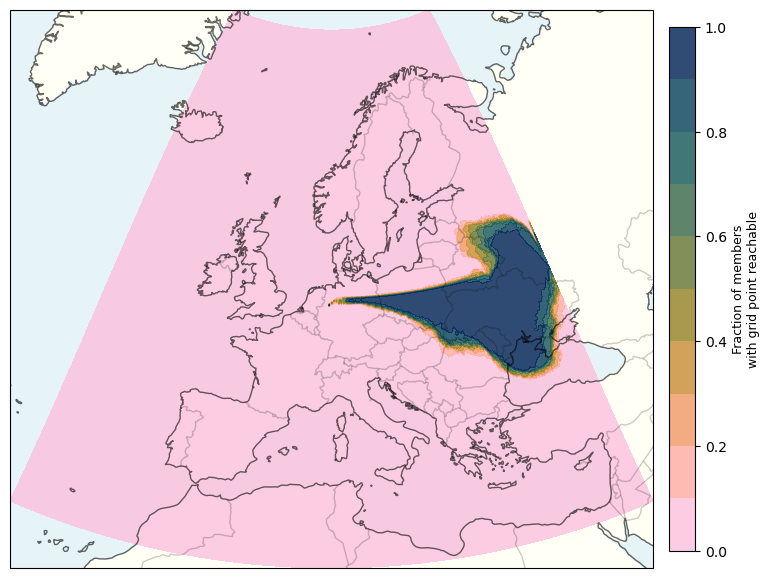

: 

: 

In [ ]:
figures = rp.plot_probabilistic_from_nc(RUN_DIR, MEMBERS, START_LAT, START_LON)

for name, fig in figures.items():
    print(f"--- {name} ---")
    plt.figure(fig.number)
    plt.show()